# 07 — Paper-informed TEMPTED and MEFISTO plots (Python)

Notebook 07 reads generated tables from `data/plot_data/<run_id>/` and writes
all PNGs into the exact same `data/figures/<run_id>/` directory used by notebook 06.

Generated CSV/audit outputs stay in `plot_data`; the figure directory contains
figures only.

The circular Greengenes plot detects dimensions independently for each method:
one ring for every TEMPTED component and one ring for every MEFISTO factor.
The rings are unlabeled on the plot itself; explanatory text is placed below the figure.


In [1]:
from datetime import datetime
from pathlib import Path
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Bio import Phylo
from matplotlib.colors import TwoSlopeNorm
from matplotlib.font_manager import FontProperties
from scipy.optimize import linear_sum_assignment
from scipy.stats import mannwhitneyu, ranksums

PRIMARY_METRIC = "balanced_accuracy"
TOP_FEATURES = 20
CIRCULAR_TREE_GENERA = 16

# Analysis contrast used throughout the figures.
# Finland and Estonia are combined before plotting and testing.
LABEL_MAP = {
    "FIN": "FIN/EST",
    "FINLAND": "FIN/EST",
    "EST": "FIN/EST",
    "ESTONIA": "FIN/EST",
    "RUS": "RUS",
    "RUSSIA": "RUS",
}
GROUP_ORDER = ["FIN/EST", "RUS"]
GROUP_COLORS = {"FIN/EST": "#0072E8", "RUS": "#F03B20"}

def normalize_group(value):
    key = str(value).strip().upper()
    return LABEL_MAP.get(key, str(value).strip())

def display_dimension(method, column):
    number = str(column).split("_")[-1]
    return f"Component {number}" if method == "TEMPTED" else f"Factor {number}"


root = Path(".") if Path("data").exists() else Path("..")

def newest_complete_directory(folder, required_files=(), required_glob=None):
    folders = sorted(
        (path for path in folder.iterdir() if path.is_dir() and not path.name.startswith(".")),
        reverse=True,
    )
    for path in folders:
        files_ok = all((path / filename).exists() for filename in required_files)
        glob_ok = True if required_glob is None else any(path.glob(required_glob))
        if files_ok and glob_ok:
            return path
    requirements = list(required_files)
    if required_glob:
        requirements.append(required_glob)
    raise FileNotFoundError(
        f"No completed run found in {folder}. Required: {', '.join(requirements)}"
    )

# Notebook 06 creates plot_data/<run_id> and figures/<run_id>.
# Read the newest complete plot-data run and reuse its run id for every PNG.
plot_data_folder = newest_complete_directory(
    root / "data" / "plot_data",
    required_files=(
        "subject_scores.csv",
        "sample_factors.csv",
        "feature_loadings.csv",
        "trajectory_summary.csv",
        "log_ratio_summary.csv",
        "loading_stability.csv",
        "loading_resamples.csv",
    ),
)
report_folder = newest_complete_directory(
    root / "data" / "reports",
    required_files=("all_metrics.csv", "confusion_counts.csv"),
)
tempted_run = newest_complete_directory(
    root / "data" / "tempted",
    required_glob="batch_*/feature_loadings.csv*",
)
mefisto_run = newest_complete_directory(
    root / "data" / "mefisto",
    required_glob="batch_*/feature_loadings.csv*",
)

run_id = plot_data_folder.name
output = root / "data" / "figures" / run_id
output.mkdir(parents=True, exist_ok=True)

subject_scores = pd.read_csv(plot_data_folder / "subject_scores.csv")
sample_factors = pd.read_csv(plot_data_folder / "sample_factors.csv")
feature_loadings = pd.read_csv(plot_data_folder / "feature_loadings.csv")
trajectory_summary = pd.read_csv(plot_data_folder / "trajectory_summary.csv")
log_ratio_summary = pd.read_csv(plot_data_folder / "log_ratio_summary.csv")
log_ratios_path = plot_data_folder / "log_ratios.csv"
log_ratios = pd.read_csv(log_ratios_path) if log_ratios_path.exists() else pd.DataFrame()
loading_stability = pd.read_csv(plot_data_folder / "loading_stability.csv")

resample_path = plot_data_folder / "loading_resamples.csv"
loading_resamples = pd.read_csv(resample_path) if resample_path.exists() else pd.DataFrame()

metrics = pd.read_csv(report_folder / "all_metrics.csv")
confusion = pd.read_csv(report_folder / "confusion_counts.csv")

# Apply the FIN/EST versus RUS contrast consistently.
for frame in [subject_scores, sample_factors, trajectory_summary, log_ratio_summary, log_ratios]:
    if len(frame) and "label" in frame.columns:
        frame["label"] = frame["label"].map(normalize_group)

if len(confusion):
    confusion["truth"] = confusion["truth"].map(normalize_group)
    confusion["predicted"] = confusion["predicted"].map(normalize_group)
    confusion = (
        confusion.groupby(["method", "truth", "predicted"], as_index=False)["count"]
        .sum()
    )

# Recompute summaries after combining Finland and Estonia so medians and
# interquartile ranges reflect the pooled FIN/EST samples rather than an
# average of two previously summarized curves.
def summarize_longitudinal(frame, value_columns, value_name):
    if not len(frame):
        return pd.DataFrame()
    long = frame.melt(
        id_vars=[column for column in ["method", "sample_id", "subject_id", "time", "label"] if column in frame.columns],
        value_vars=value_columns,
        var_name="factor",
        value_name=value_name,
    )
    long["time_bin"] = pd.cut(long["time"], bins=12, include_lowest=True, labels=False)
    return (
        long.groupby(["method", "factor", "label", "time_bin"], as_index=False)
        .agg(
            time=("time", "median"),
            median=(value_name, "median"),
            lower=(value_name, lambda values: values.quantile(0.25)),
            upper=(value_name, lambda values: values.quantile(0.75)),
        )
    )

sample_dimensions = [column for column in sample_factors.columns if column.startswith("factor_")]
if sample_dimensions:
    trajectory_summary = summarize_longitudinal(sample_factors, sample_dimensions, "latent_value")

if len(log_ratios) and "log_ratio" in log_ratios.columns:
    log_ratio_summary = (
        log_ratios.assign(
            time_bin=pd.cut(log_ratios["time"], bins=12, include_lowest=True, labels=False)
        )
        .groupby(["method", "factor", "label", "time_bin"], as_index=False)
        .agg(
            time=("time", "median"),
            median=("log_ratio", "median"),
            lower=("log_ratio", lambda values: values.quantile(0.25)),
            upper=("log_ratio", lambda values: values.quantile(0.75)),
        )
    )

print("Plot data:", plot_data_folder)
print("Report:", report_folder)
print("TEMPTED model run:", tempted_run)
print("MEFISTO model run:", mefisto_run)
print("Output:", output)
print("Loading resamples:", len(loading_resamples))


Plot data: ../data/plot_data/20260807_032009
Report: ../data/reports/20260807_031958
TEMPTED model run: ../data/tempted/20260806_210539
MEFISTO model run: ../data/mefisto/20260806_211226
Output: ../data/figures/20260807_032009
Loading resamples: 856


In [2]:
def save_figure(figure, filename):
    figure.savefig(output / filename, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(figure)

def robust_limits(values, padding=0.08, lower_quantile=0.01, upper_quantile=0.99):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return (-1, 1)
    low, high = np.quantile(values, [lower_quantile, upper_quantile])
    if low == high:
        spread = max(abs(low), 1) * 0.1
        return low - spread, high + spread
    margin = (high - low) * padding
    return low - margin, high + margin

def bh_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    adjusted = np.full(len(p), np.nan)
    valid = np.isfinite(p)
    if not valid.any():
        return adjusted
    valid_indices = np.where(valid)[0]
    order = valid_indices[np.argsort(p[valid])]
    running = 1.0
    for reverse_rank, index in enumerate(order[::-1], start=1):
        rank = len(order) - reverse_rank + 1
        running = min(running, p[index] * len(order) / rank)
        adjusted[index] = min(running, 1.0)
    return adjusted

def stars(p_value):
    if not np.isfinite(p_value):
        return ""
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return ""

def normalized_confusion(rows):
    matrix = rows.pivot(index="truth", columns="predicted", values="count").fillna(0)
    percentages = matrix.div(matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100
    return matrix, percentages


## Held-out performance and classification


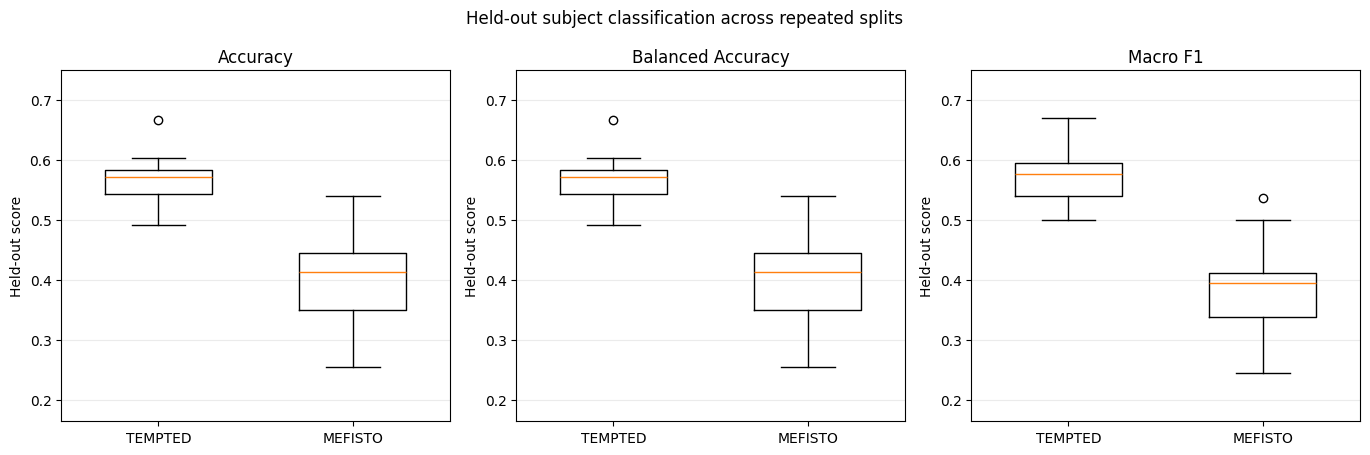

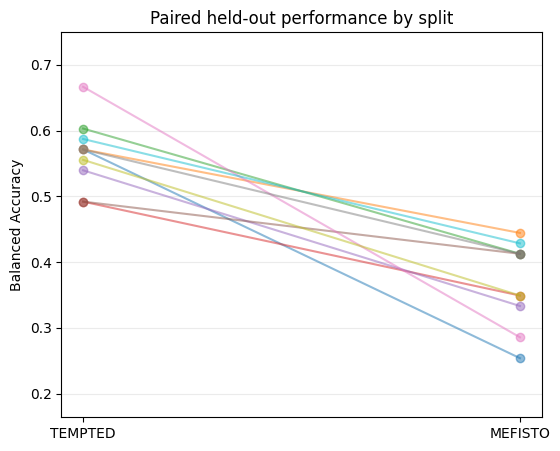

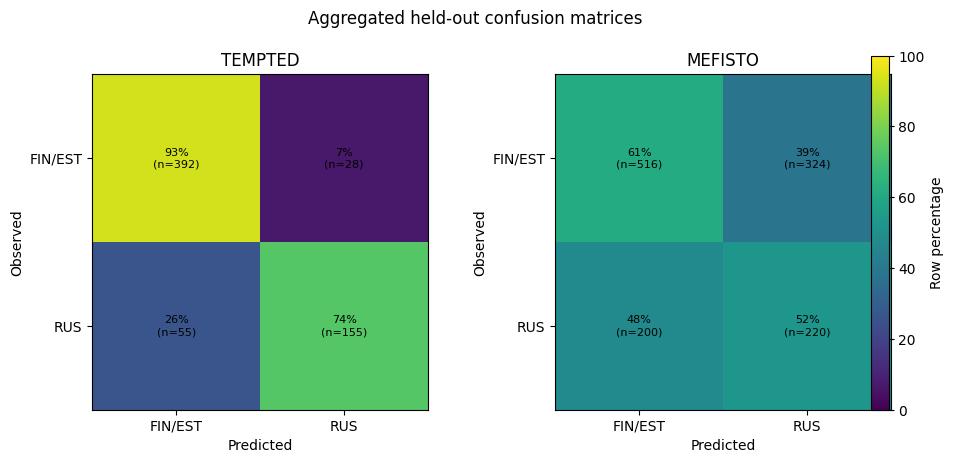

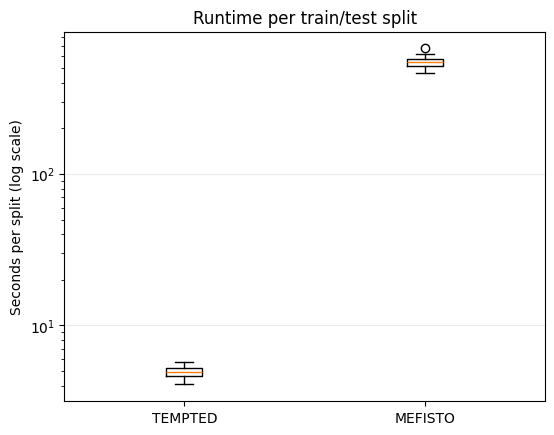

In [3]:
metric_columns = [column for column in ["accuracy", "balanced_accuracy", "macro_f1"] if column in metrics]
figure, axes = plt.subplots(1, len(metric_columns), figsize=(4.6 * len(metric_columns), 4.6))
axes = np.atleast_1d(axes)

all_metric_values = metrics[metric_columns].to_numpy(float)
metric_low = max(0, np.nanmin(all_metric_values) - 0.08)
metric_high = min(1, np.nanmax(all_metric_values) + 0.08)

for axis, metric_name in zip(axes, metric_columns):
    methods = [method for method in ["TEMPTED", "MEFISTO"] if method in metrics["method"].unique()]
    values = [metrics.loc[metrics["method"] == method, metric_name].dropna() for method in methods]
    axis.boxplot(values, tick_labels=methods, widths=0.55)
    axis.set_title(metric_name.replace("_", " ").title())
    axis.set_ylim(metric_low, metric_high)
    axis.set_ylabel("Held-out score")
    axis.grid(axis="y", alpha=0.25)

figure.suptitle("Held-out subject classification across repeated splits")
figure.tight_layout()
save_figure(figure, "07_classification_metrics.png")

paired = metrics.pivot_table(index="batch", columns="method", values=PRIMARY_METRIC).dropna()
if {"TEMPTED", "MEFISTO"}.issubset(paired.columns):
    figure, axis = plt.subplots(figsize=(6.2, 5))
    for _, row in paired.iterrows():
        axis.plot(["TEMPTED", "MEFISTO"], [row["TEMPTED"], row["MEFISTO"]], marker="o", alpha=0.5)
    axis.set_ylim(metric_low, metric_high)
    axis.set_ylabel(PRIMARY_METRIC.replace("_", " ").title())
    axis.set_title("Paired held-out performance by split")
    axis.grid(axis="y", alpha=0.25)
    save_figure(figure, "07_paired_batch_performance.png")

methods = [method for method in ["TEMPTED", "MEFISTO"] if method in confusion["method"].unique()]
figure, axes = plt.subplots(1, len(methods), figsize=(5.2 * len(methods), 4.6))
axes = np.atleast_1d(axes)

for axis, method in zip(axes, methods):
    counts, percentages = normalized_confusion(confusion[confusion["method"] == method])
    image = axis.imshow(percentages, vmin=0, vmax=100)
    axis.set_xticks(range(len(percentages.columns)), percentages.columns)
    axis.set_yticks(range(len(percentages.index)), percentages.index)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Observed")
    axis.set_title(method)
    for y in range(percentages.shape[0]):
        for x in range(percentages.shape[1]):
            pct = percentages.iloc[y, x]
            count = counts.iloc[y, x]
            axis.text(x, y, f"{pct:.0f}%\n(n={int(count)})", ha="center", va="center", fontsize=8)

figure.colorbar(image, ax=list(axes), fraction=0.025, pad=0.04, label="Row percentage")
figure.suptitle("Aggregated held-out confusion matrices")
figure.subplots_adjust(top=0.84, wspace=0.35)
save_figure(figure, "07_confusion_matrices.png")

figure, axis = plt.subplots(figsize=(6.2, 4.8))
runtime = [metrics.loc[metrics["method"] == method, "elapsed_seconds"].dropna() for method in methods]
axis.boxplot(runtime, tick_labels=methods)
axis.set_yscale("log")
axis.set_ylabel("Seconds per split (log scale)")
axis.set_title("Runtime per train/test split")
axis.grid(axis="y", alpha=0.25)
save_figure(figure, "07_runtime.png")


## Method-appropriate latent representations


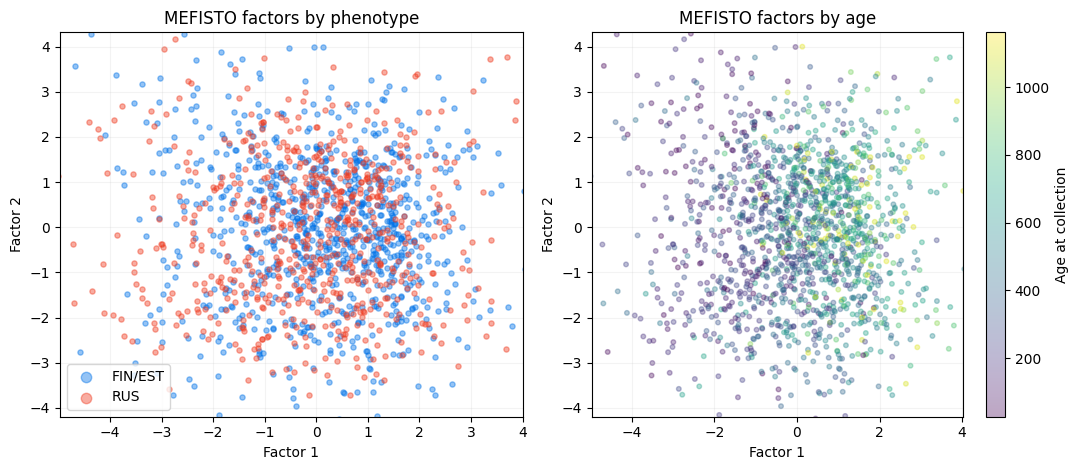

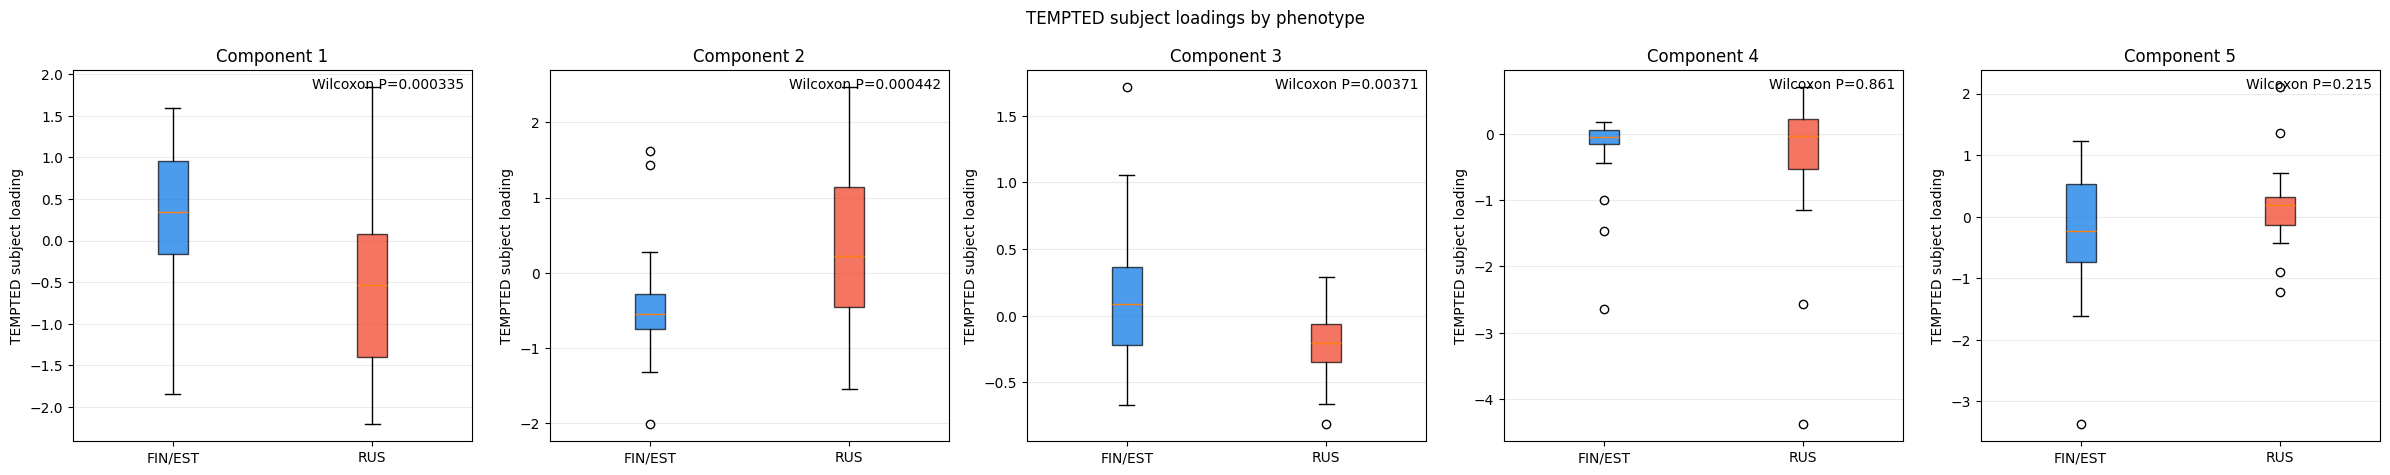

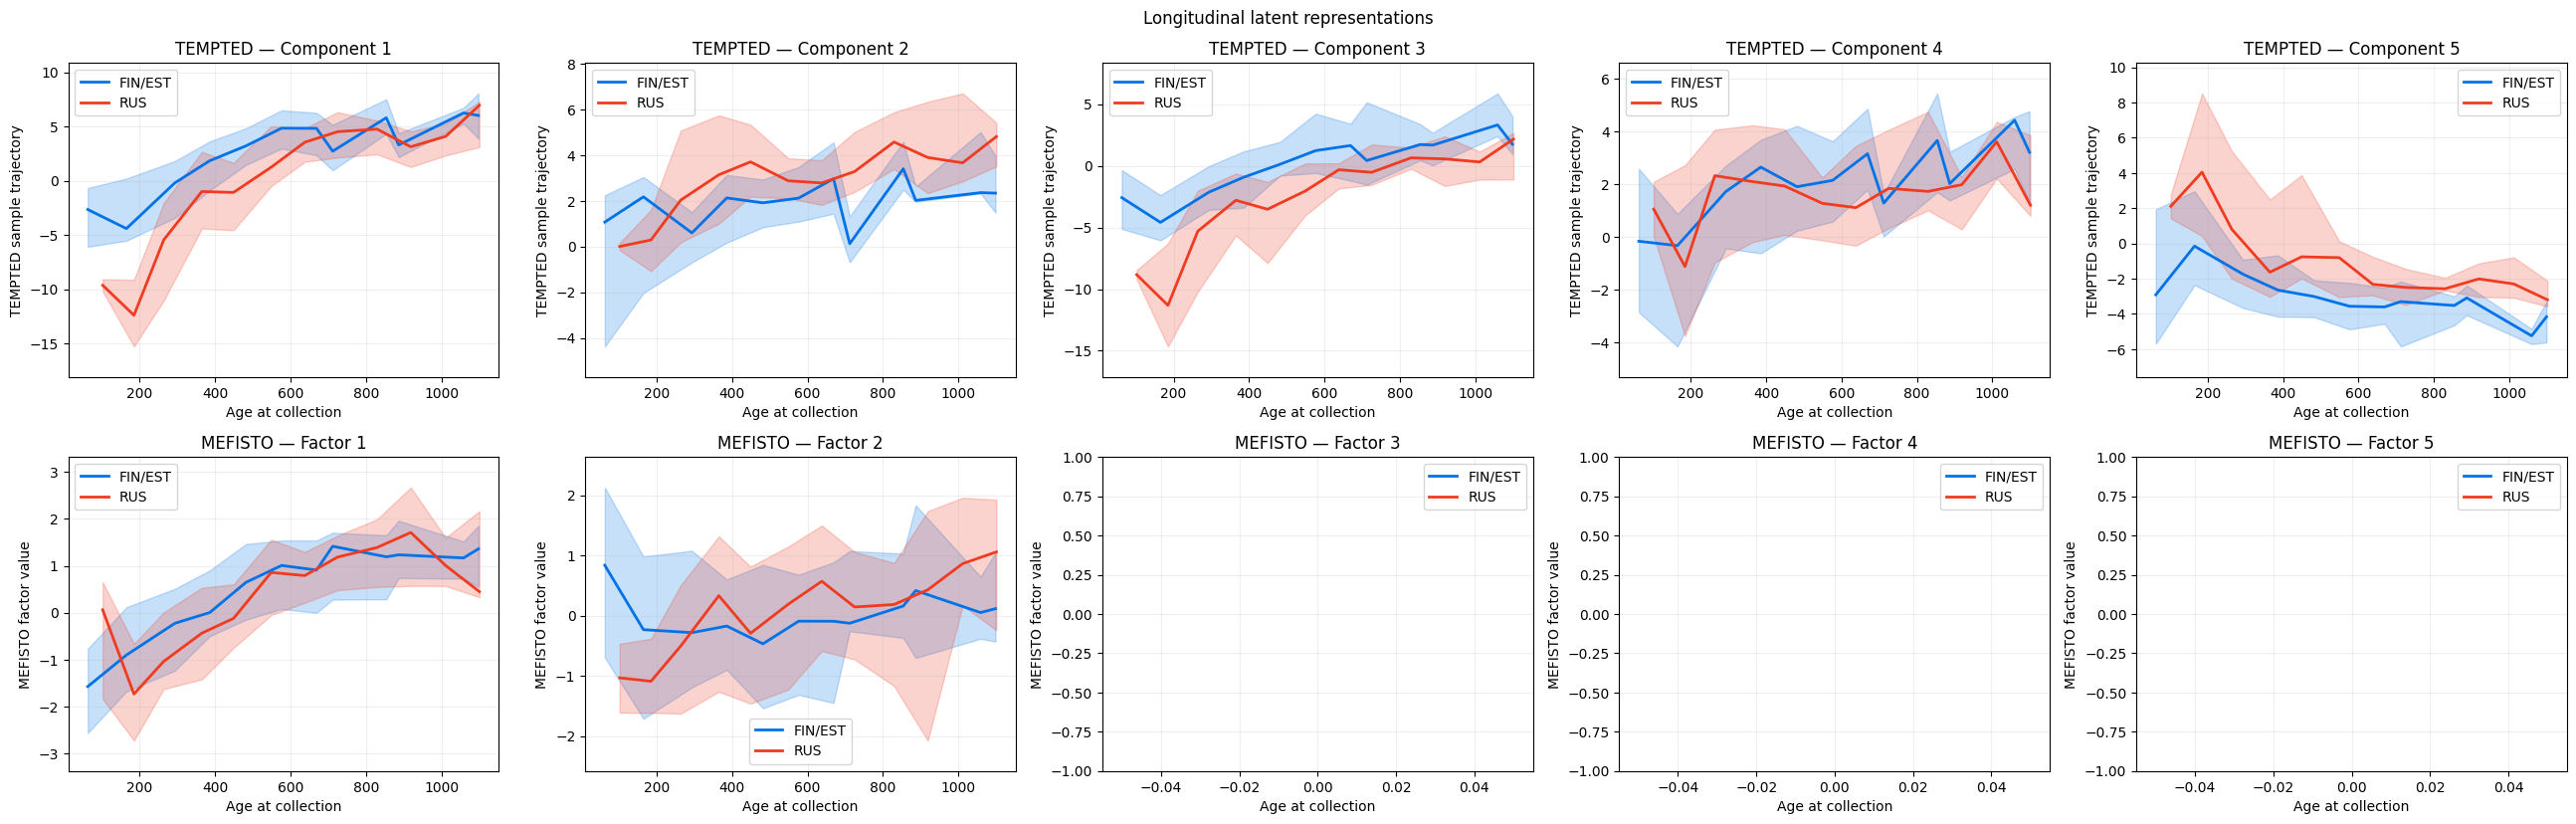

In [4]:
factor_columns = [column for column in sample_factors.columns if column.startswith("factor_")]

# MEFISTO: fitted factor values, as in the microbiome application in Fig. 3a-b.
mefisto_samples = sample_factors[sample_factors["method"] == "MEFISTO"].copy()
if len(factor_columns) >= 2 and len(mefisto_samples):
    figure, axes = plt.subplots(1, 2, figsize=(11, 4.8))
    for label in GROUP_ORDER:
        rows = mefisto_samples[mefisto_samples["label"] == label]
        if len(rows):
            axes[0].scatter(
                rows[factor_columns[0]], rows[factor_columns[1]],
                s=14, alpha=0.42, label=label,
                color=GROUP_COLORS[label], rasterized=True,
            )
    axes[0].set_xlabel("Factor 1")
    axes[0].set_ylabel("Factor 2")
    axes[0].set_title("MEFISTO factors by phenotype")
    axes[0].legend(markerscale=2)

    scatter = axes[1].scatter(
        mefisto_samples[factor_columns[0]],
        mefisto_samples[factor_columns[1]],
        c=mefisto_samples["time"],
        s=11,
        alpha=0.35,
        rasterized=True,
    )
    axes[1].set_xlabel("Factor 1")
    axes[1].set_ylabel("Factor 2")
    axes[1].set_title("MEFISTO factors by age")
    figure.colorbar(scatter, ax=axes[1], label="Age at collection")

    for axis in axes:
        axis.set_xlim(*robust_limits(mefisto_samples[factor_columns[0]]))
        axis.set_ylim(*robust_limits(mefisto_samples[factor_columns[1]]))
        axis.grid(alpha=0.15)

    figure.tight_layout()
    save_figure(figure, "07_mefisto_factor_embedding.png")

# TEMPTED: subject loadings are the proper subject-level representation.
tempted_subjects = subject_scores[subject_scores["method"] == "TEMPTED"].copy()
tempted_factors = [column for column in tempted_subjects.columns if column.startswith("factor_")]
if tempted_factors:
    figure, axes = plt.subplots(1, len(tempted_factors), figsize=(4.8 * len(tempted_factors), 4.8))
    axes = np.atleast_1d(axes)
    labels = [label for label in GROUP_ORDER if label in tempted_subjects["label"].unique()]
    for axis, factor in zip(axes, tempted_factors):
        groups = [tempted_subjects.loc[tempted_subjects["label"] == label, factor].dropna() for label in labels]
        boxplot = axis.boxplot(groups, tick_labels=labels, patch_artist=True)
        for patch, label in zip(boxplot["boxes"], labels):
            patch.set_facecolor(GROUP_COLORS[label])
            patch.set_alpha(0.70)
        axis.set_title(display_dimension("TEMPTED", factor))
        axis.set_ylabel("TEMPTED subject loading")
        axis.grid(axis="y", alpha=0.25)
        if len(groups) == 2 and all(len(group) for group in groups):
            p_value = ranksums(groups[0], groups[1]).pvalue
            axis.text(0.98, 0.98, f"Wilcoxon P={p_value:.3g}", transform=axis.transAxes, ha="right", va="top")
    figure.suptitle("TEMPTED subject loadings by phenotype")
    figure.tight_layout()
    save_figure(figure, "07_tempted_subject_loadings.png")

# Longitudinal curves: keep free y-scales because TEMPTED Eq. (2) values and
# MEFISTO fitted factors are on different model-specific scales.
methods = [method for method in ["TEMPTED", "MEFISTO"] if method in trajectory_summary["method"].unique()]
factors = list(trajectory_summary["factor"].drop_duplicates())
figure, axes = plt.subplots(len(methods), len(factors), figsize=(5.2 * len(factors), 4.2 * len(methods)), squeeze=False)

for row_index, method in enumerate(methods):
    for column_index, factor in enumerate(factors):
        axis = axes[row_index, column_index]
        rows = trajectory_summary[
            (trajectory_summary["method"] == method) &
            (trajectory_summary["factor"] == factor)
        ]
        for label in GROUP_ORDER:
            group = rows[rows["label"] == label].sort_values("time")
            if len(group):
                axis.plot(
                    group["time"], group["median"], label=label,
                    color=GROUP_COLORS[label], linewidth=2.0,
                )
                axis.fill_between(
                    group["time"], group["lower"], group["upper"],
                    color=GROUP_COLORS[label], alpha=0.22,
                )
        axis.set_title(f"{method} — {display_dimension(method, factor)}")
        axis.set_xlabel("Age at collection")
        axis.set_ylabel(
            "TEMPTED sample trajectory" if method == "TEMPTED"
            else "MEFISTO factor value"
        )
        axis.grid(alpha=0.2)
        if len(rows):
            axis.set_ylim(*robust_limits(np.r_[rows["lower"], rows["upper"]], padding=0.12, lower_quantile=0, upper_quantile=1))
        axis.legend()

figure.suptitle("Longitudinal latent representations")
figure.tight_layout()
save_figure(figure, "07_latent_trajectory_comparison.png")


## Feature signatures and direct comparisons


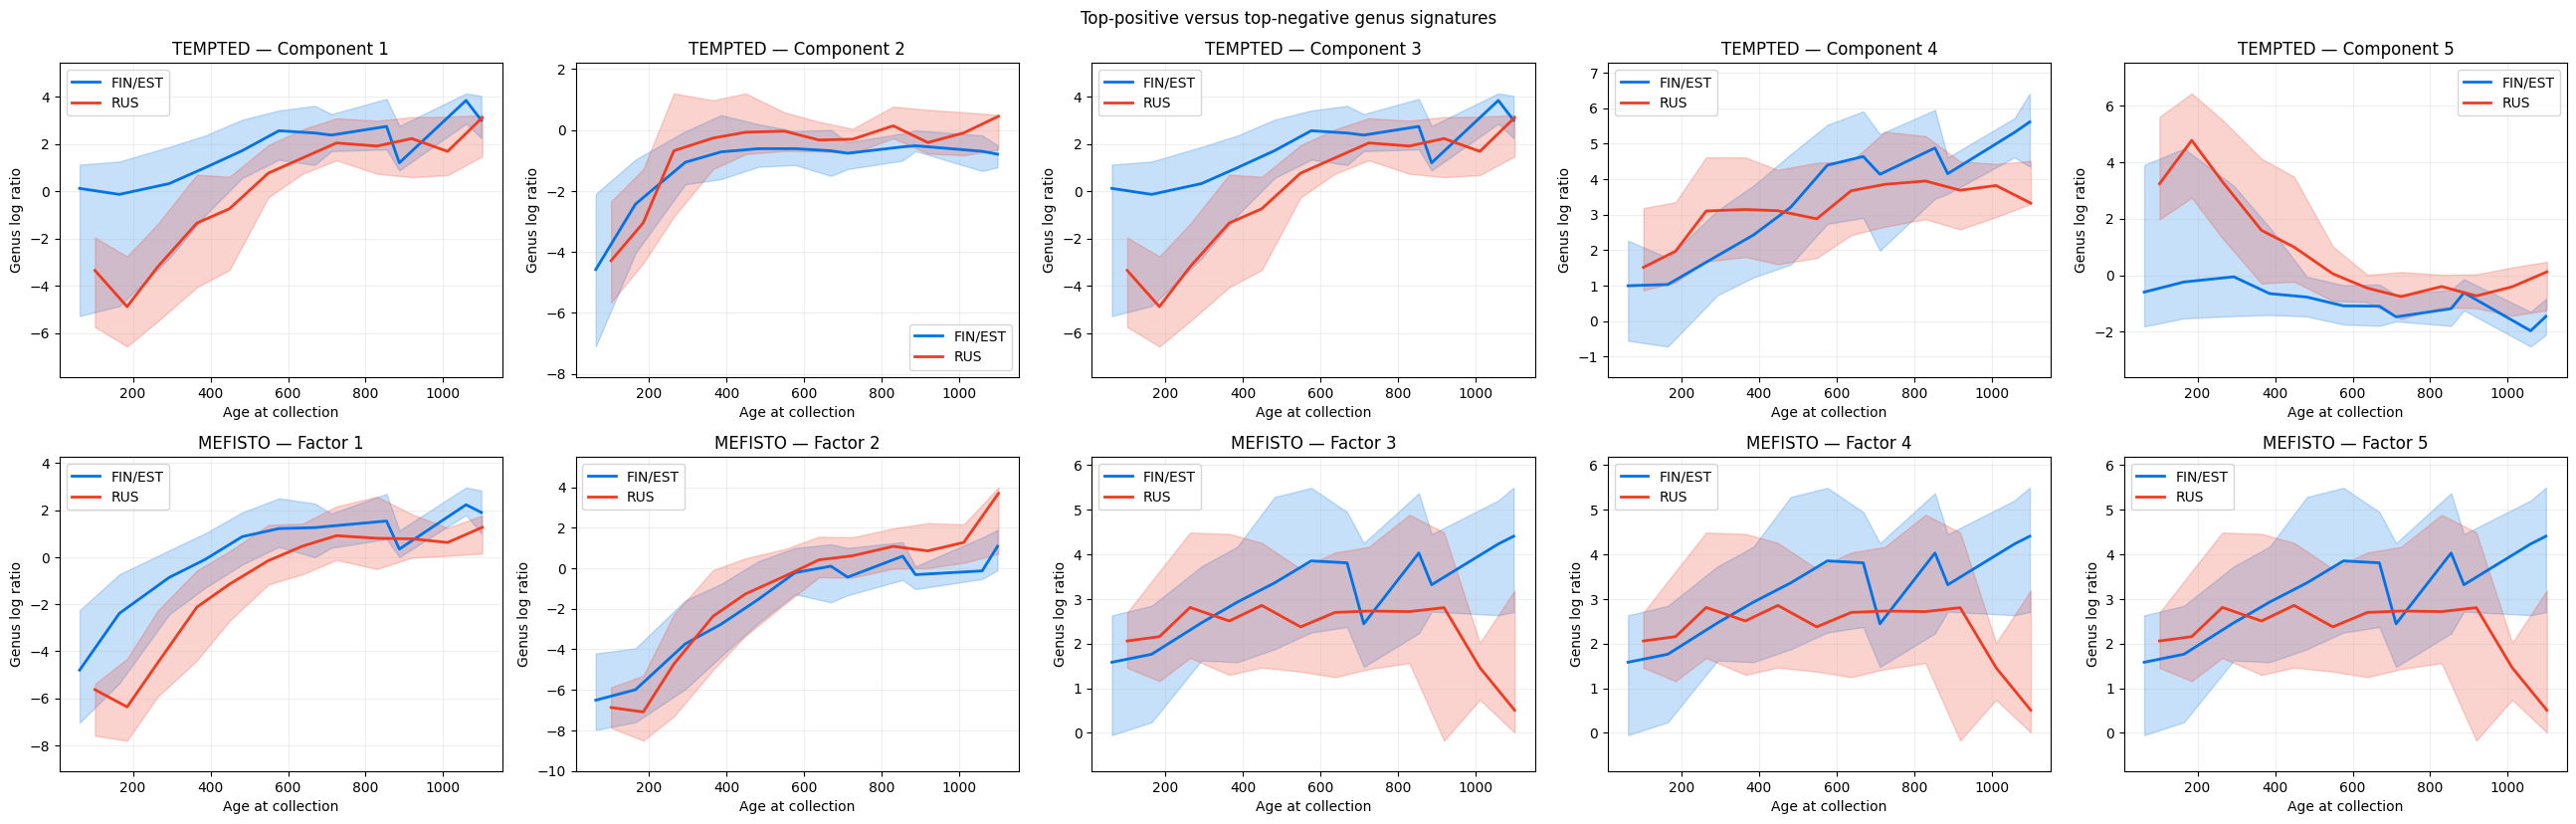

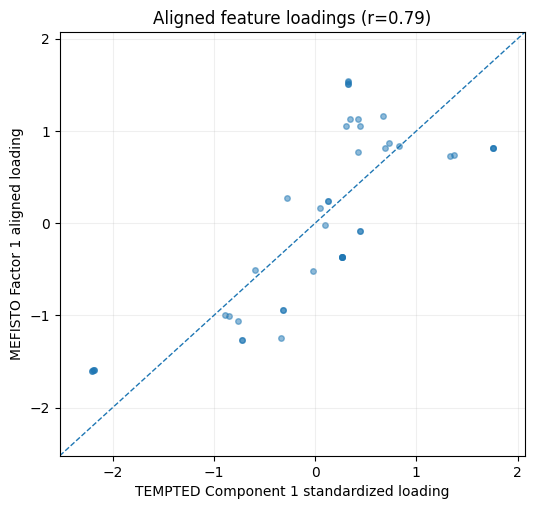

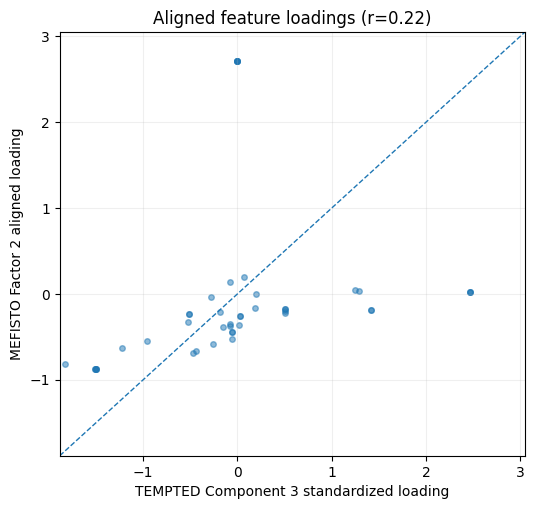

Loading dimensions:
  TEMPTED components: ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']
  MEFISTO factors: ['factor_1', 'factor_2']


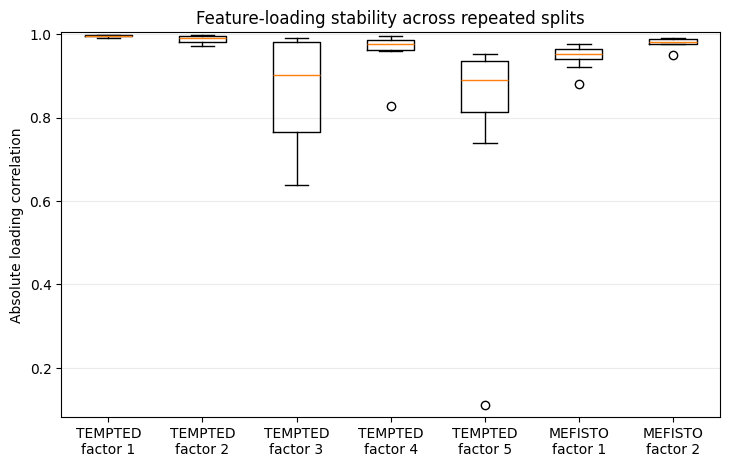

In [5]:
# Genus log-ratio trajectories are a TEMPTED paper idiom and are also an
# interpretable analogous signature for MEFISTO.
methods = [method for method in ["TEMPTED", "MEFISTO"] if method in log_ratio_summary["method"].unique()]
factors = list(log_ratio_summary["factor"].drop_duplicates())
figure, axes = plt.subplots(len(methods), len(factors), figsize=(5.2 * len(factors), 4.2 * len(methods)), squeeze=False)

for row_index, method in enumerate(methods):
    for column_index, factor in enumerate(factors):
        axis = axes[row_index, column_index]
        rows = log_ratio_summary[
            (log_ratio_summary["method"] == method) &
            (log_ratio_summary["factor"] == factor)
        ]
        for label in GROUP_ORDER:
            group = rows[rows["label"] == label].sort_values("time")
            if len(group):
                axis.plot(
                    group["time"], group["median"], label=label,
                    color=GROUP_COLORS[label], linewidth=2.0,
                )
                axis.fill_between(
                    group["time"], group["lower"], group["upper"],
                    color=GROUP_COLORS[label], alpha=0.22,
                )
        axis.set_title(f"{method} — {display_dimension(method, factor)}")
        axis.set_xlabel("Age at collection")
        axis.set_ylabel("Genus log ratio")
        axis.grid(alpha=0.2)
        if len(rows):
            axis.set_ylim(*robust_limits(np.r_[rows["lower"], rows["upper"]], padding=0.12, lower_quantile=0, upper_quantile=1))
        axis.legend()

figure.suptitle("Top-positive versus top-negative genus signatures")
figure.tight_layout()
save_figure(figure, "07_log_ratio_trajectory_comparison.png")


# Align component/factor order and sign before comparing feature weights.
# Detect dimensions separately by method. A wider model can therefore have
# more TEMPTED components than MEFISTO factors (or vice versa) without creating
# all-NaN columns in the cross-method correlation matrix.
def available_loading_dimensions(method):
    rows = feature_loadings[feature_loadings["method"] == method]
    return [
        column for column in rows.columns
        if column.startswith("factor_")
        and pd.to_numeric(rows[column], errors="coerce").notna().any()
    ]


def finite_correlation(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    if keep.sum() < 3:
        return np.nan
    x = x[keep]
    y = y[keep]
    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]


tempted_dimensions = available_loading_dimensions("TEMPTED")
mefisto_dimensions = available_loading_dimensions("MEFISTO")

alignment_rows = []
if tempted_dimensions and mefisto_dimensions:
    tempted_loadings_wide = (
        feature_loadings[feature_loadings["method"] == "TEMPTED"]
        .set_index("feature_id")[tempted_dimensions]
    )
    mefisto_loadings_wide = (
        feature_loadings[feature_loadings["method"] == "MEFISTO"]
        .set_index("feature_id")[mefisto_dimensions]
    )

    shared = tempted_loadings_wide.index.intersection(mefisto_loadings_wide.index)
    tempted_matrix = tempted_loadings_wide.loc[shared].to_numpy(float)
    mefisto_matrix = mefisto_loadings_wide.loc[shared].to_numpy(float)

    correlation = np.full(
        (len(tempted_dimensions), len(mefisto_dimensions)),
        np.nan,
        dtype=float,
    )
    for i in range(len(tempted_dimensions)):
        for j in range(len(mefisto_dimensions)):
            correlation[i, j] = finite_correlation(
                tempted_matrix[:, i],
                mefisto_matrix[:, j],
            )

    # The Hungarian algorithm cannot accept NaN/Inf. Invalid pairs receive a
    # very large cost and are ignored after assignment.
    cost = np.where(np.isfinite(correlation), -np.abs(correlation), 1e6)
    row_indices, column_indices = linear_sum_assignment(cost)

    for tempted_index, mefisto_index in zip(row_indices, column_indices):
        r = correlation[tempted_index, mefisto_index]
        if not np.isfinite(r):
            continue

        tempted_dimension = tempted_dimensions[tempted_index]
        mefisto_dimension = mefisto_dimensions[mefisto_index]
        sign = 1 if r >= 0 else -1

        x = tempted_matrix[:, tempted_index]
        y = mefisto_matrix[:, mefisto_index] * sign
        keep = np.isfinite(x) & np.isfinite(y)
        x = x[keep]
        y = y[keep]

        x_sd = np.std(x)
        y_sd = np.std(y)
        if len(x) < 3 or x_sd == 0 or y_sd == 0:
            continue

        x = (x - np.mean(x)) / x_sd
        y = (y - np.mean(y)) / y_sd

        absolute_correlation = abs(r)
        tempted_number = int(tempted_dimension.split("_")[-1])
        mefisto_number = int(mefisto_dimension.split("_")[-1])

        if absolute_correlation >= 0.20:
            figure, axis = plt.subplots(figsize=(6, 5.5))
            axis.scatter(x, y, s=16, alpha=0.5, rasterized=True)
            low = min(*robust_limits(np.r_[x, y]))
            high = max(*robust_limits(np.r_[x, y]))
            axis.plot([low, high], [low, high], linestyle="--", linewidth=1)
            axis.set_xlim(low, high)
            axis.set_ylim(low, high)
            axis.set_xlabel(f"TEMPTED Component {tempted_number} standardized loading")
            axis.set_ylabel(f"MEFISTO Factor {mefisto_number} aligned loading")
            axis.set_title(f"Aligned feature loadings (r={absolute_correlation:.2f})")
            axis.grid(alpha=0.2)
            save_figure(
                figure,
                f"07_aligned_loading_concordance_component_{tempted_number}.png",
            )
        else:
            print(
                f"Skipped loading-concordance plot for TEMPTED Component {tempted_number}: "
                f"best matched MEFISTO Factor {mefisto_number} has r={absolute_correlation:.2f}."
            )

        alignment_rows.append({
            "tempted_component": tempted_number,
            "mefisto_factor": mefisto_number,
            "sign_flipped": sign == -1,
            "absolute_correlation": absolute_correlation,
            "shared_finite_features": len(x),
        })

print("Loading dimensions:")
print("  TEMPTED components:", tempted_dimensions)
print("  MEFISTO factors:", mefisto_dimensions)

pd.DataFrame(alignment_rows).to_csv(
    plot_data_folder / "factor_alignment.csv",
    index=False,
)

if len(loading_stability):
    figure, axis = plt.subplots(figsize=(8.5, 5))
    groups, labels = [], []
    for method in ["TEMPTED", "MEFISTO"]:
        for factor in sorted(loading_stability["factor"].drop_duplicates()):
            values = loading_stability.loc[
                (loading_stability["method"] == method) &
                (loading_stability["factor"] == factor),
                "absolute_correlation",
            ].dropna()
            if len(values):
                groups.append(values)
                labels.append(f"{method}\n{factor.replace('_', ' ')}")
    axis.boxplot(groups, tick_labels=labels)
    minimum = min(float(np.min(group)) for group in groups)
    axis.set_ylim(max(0, minimum - 0.03), 1.005)
    axis.set_ylabel("Absolute loading correlation")
    axis.set_title("Feature-loading stability across repeated splits")
    axis.grid(axis="y", alpha=0.25)
    save_figure(figure, "07_loading_stability_comparison.png")


## MEFISTO model diagnostics


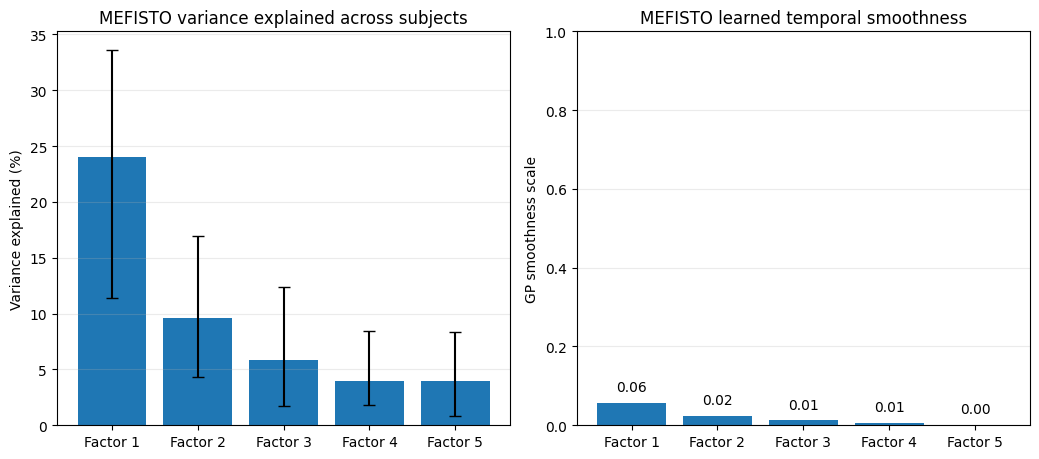

In [6]:
batch_name = sorted(path.name for path in mefisto_run.iterdir() if path.is_dir() and path.name.startswith("batch_"))[0]
model_path = mefisto_run / batch_name / "model.hdf5"

with h5py.File(model_path, "r") as model:
    smoothness = np.asarray(model["training_stats/scales"][:], dtype=float)
    r2_values = []
    r2_group = model["variance_explained/r2_per_factor"]
    for group_name in r2_group.keys():
        values = np.asarray(r2_group[group_name][:], dtype=float).reshape(-1)
        r2_values.append(values)
    r2_values = np.asarray(r2_values)
    median_r2 = np.nanmedian(r2_values, axis=0)
    lower_r2 = np.nanquantile(r2_values, 0.25, axis=0)
    upper_r2 = np.nanquantile(r2_values, 0.75, axis=0)

factor_labels = [f"Factor {index + 1}" for index in range(len(smoothness))]
figure, axes = plt.subplots(1, 2, figsize=(10.5, 4.7))

axes[0].bar(factor_labels, median_r2, yerr=[median_r2 - lower_r2, upper_r2 - median_r2], capsize=4)
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("MEFISTO variance explained across subjects")
axes[0].grid(axis="y", alpha=0.25)

if np.allclose(smoothness, 0):
    axes[1].set_axis_off()
    axes[1].text(
        0.5,
        0.58,
        "The saved MEFISTO model reports\nGP smoothness = 0.00 for all fitted factors.",
        ha="center",
        va="center",
        fontsize=11,
        transform=axes[1].transAxes,
    )
    axes[1].text(
        0.5,
        0.35,
        "This is a model result, not a missing plot.",
        ha="center",
        va="center",
        fontsize=9,
        transform=axes[1].transAxes,
    )
    axes[1].set_title("MEFISTO learned temporal smoothness")
else:
    axes[1].bar(factor_labels, smoothness)
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("GP smoothness scale")
    axes[1].set_title("MEFISTO learned temporal smoothness")
    axes[1].grid(axis="y", alpha=0.25)
    for index, value in enumerate(smoothness):
        axes[1].text(index, value + 0.03, f"{value:.2f}", ha="center")

figure.tight_layout()
save_figure(figure, "07_mefisto_model_diagnostics.png")


## Circular Greengenes phylogenetic factor-weight plot

The rings show genus-level mean TEMPTED component and MEFISTO factor weights. Asterisks are placed in the corresponding method/factor/genus ring cell.

Because the fitted dataset contains one modeled feature per genus rather than multiple sOTUs per genus, the paper's exact within-genus sOTU enrichment test cannot be reproduced from a single fit. The analogous test here uses genus loading estimates from repeated train/test fits:
- positive and negative directions are tested separately against their same-sign background;
- one-sided Mann–Whitney tests are used;
- P values are Benjamini–Hochberg adjusted within method, factor and direction.

The number of rings is detected automatically from the available `factor_N` columns. These columns represent TEMPTED components and MEFISTO factors. Ring numbers are not printed on the rings; instead, text below the figure explains that the rings proceed from the innermost dimension to the outermost dimension.


Phylogenetic tree source runs:
  TEMPTED: ../data/tempted/20260806_210539
  MEFISTO: ../data/mefisto/20260806_211226
  TEMPTED components: ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']
  MEFISTO factors: ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']
Circular-tree dimensions:
  TEMPTED: 5 -> ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']
  MEFISTO: 5 -> ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']


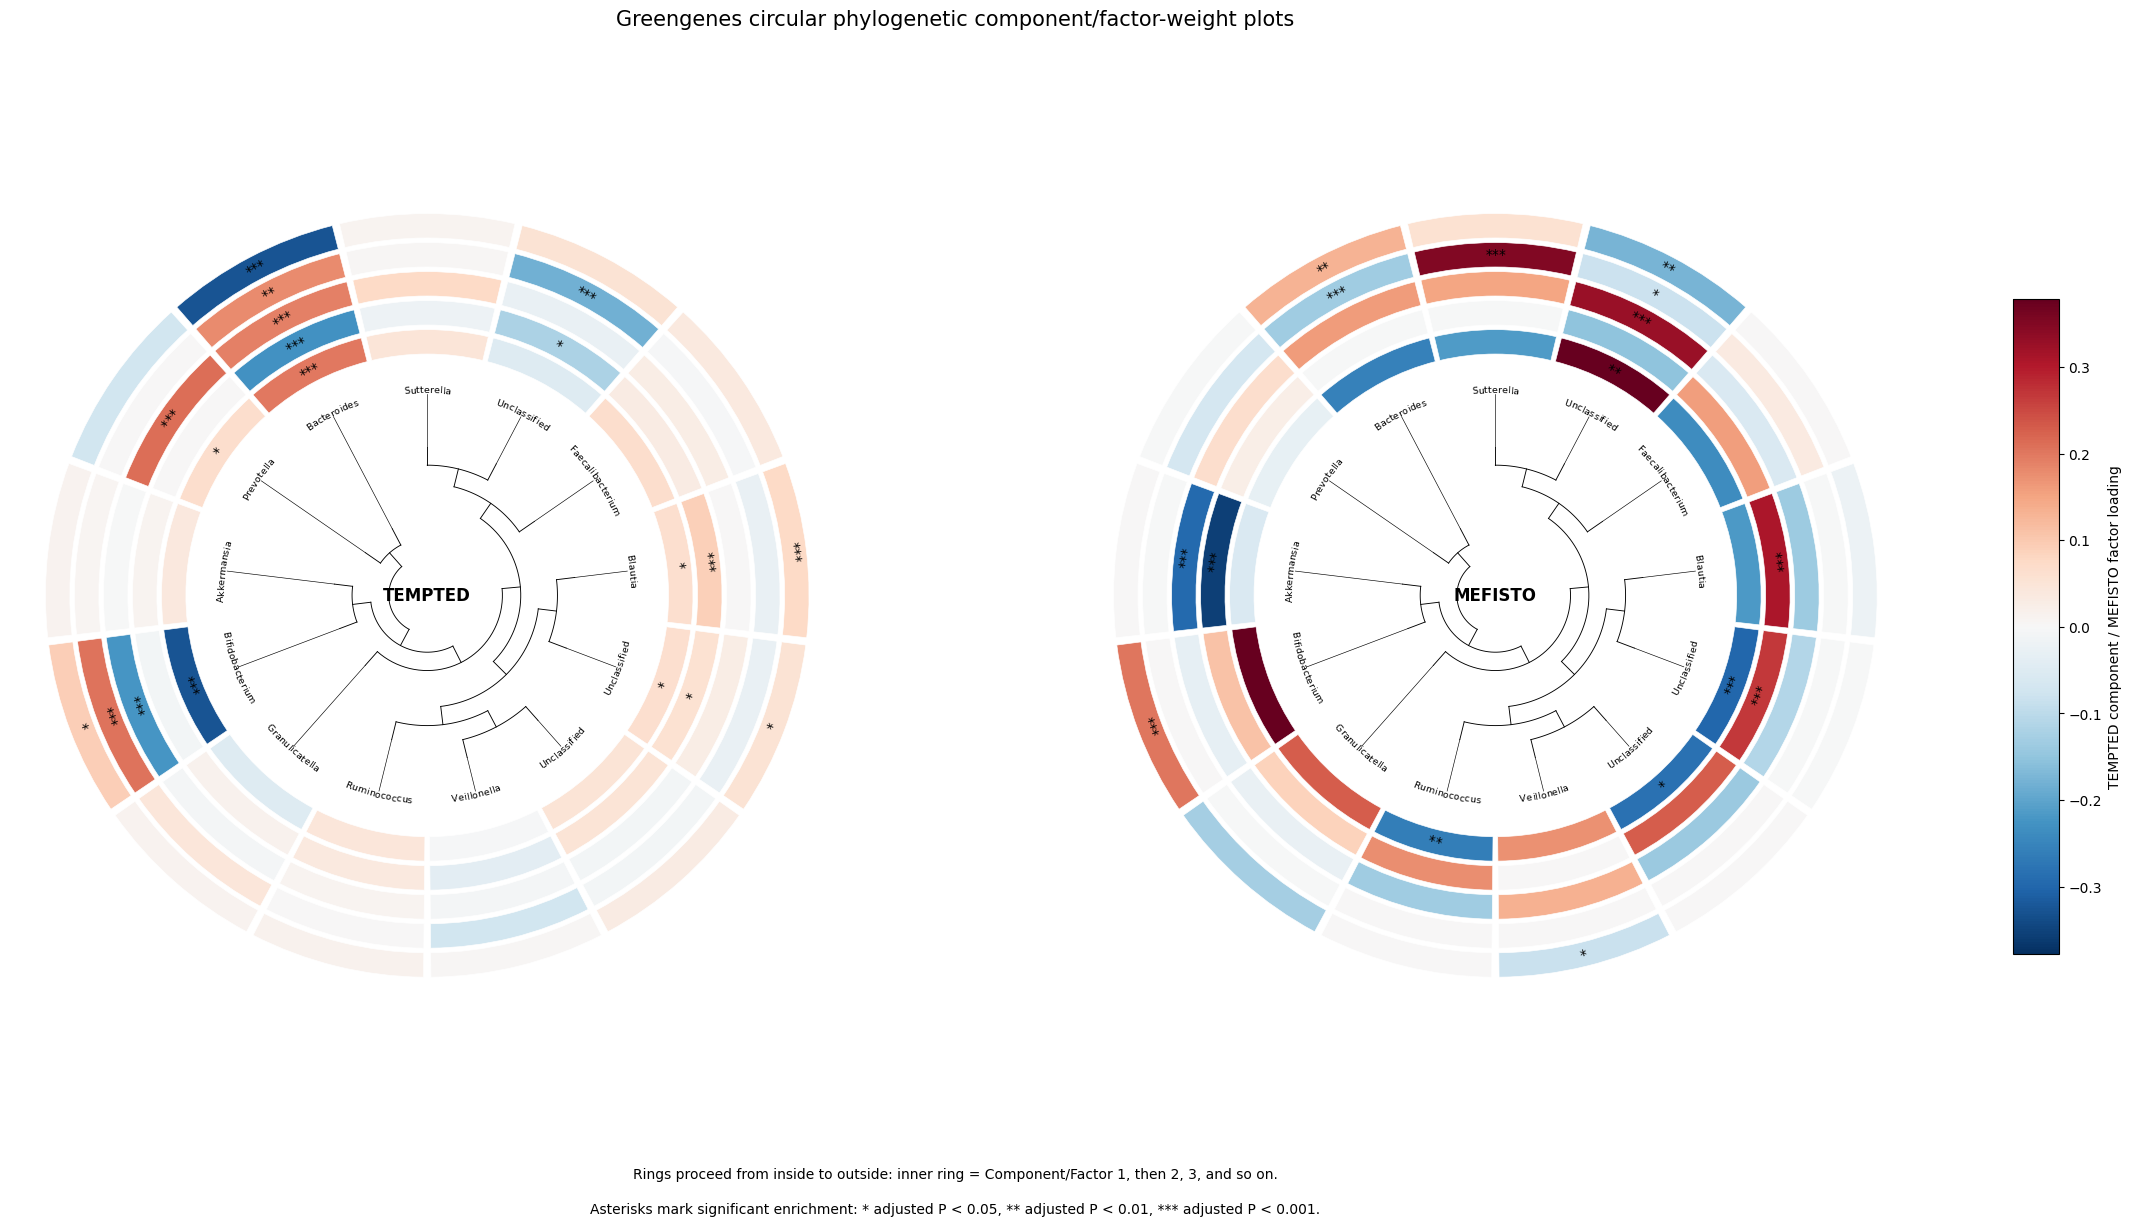

Significant circular-tree cells: 39


In [7]:
from copy import deepcopy

GREEN_GENES_TREE = root / "data" / "DIABIMMUNE" / "97_otus.tree"
GREEN_GENES_TAXONOMY = root / "data" / "DIABIMMUNE" / "97_otu_taxonomy.txt"

def canonical_taxonomy(text):
    return "|".join(part.strip() for part in str(text).replace(";", "|").split("|") if part.strip())

def genus_path(text):
    parts = canonical_taxonomy(text).split("|")
    genus_index = next((index for index, part in enumerate(parts) if part.startswith("g__")), None)
    if genus_index is None:
        return None
    return "|".join(parts[: genus_index + 1])


taxonomy = pd.read_csv(GREEN_GENES_TAXONOMY, sep="\t", names=["otu_id", "taxonomy"], dtype=str)
taxonomy["genus_path"] = taxonomy["taxonomy"].map(genus_path)

# The phylogenetic plot must reflect the fitted model runs themselves, not
# whatever dimensionality happened to be carried forward by notebook 06.
# Load every batch's feature weights directly from the newest TEMPTED and
# MEFISTO model directories. This is intentionally independent of all_metrics.
def read_feature_loadings(path):
    frame = pd.read_csv(path)
    if "feature_id" not in frame.columns:
        frame = frame.rename(columns={frame.columns[0]: "feature_id"})
    return frame


def batch_loading_files(run_folder):
    files = []
    for batch_folder in sorted(
        path for path in run_folder.iterdir()
        if path.is_dir() and path.name.startswith("batch_")
    ):
        candidates = [
            batch_folder / "feature_loadings.csv.gz",
            batch_folder / "feature_loadings.csv",
        ]
        match = next((candidate for candidate in candidates if candidate.exists()), None)
        if match is not None:
            files.append((batch_folder.name, match))
    return files


def loading_dimensions(frame):
    return sorted(
        [
            column for column in frame.columns
            if column.startswith("factor_")
            and pd.to_numeric(frame[column], errors="coerce").notna().any()
        ],
        key=lambda name: int(name.split("_")[-1]),
    )


def align_batch_loadings(reference, current):
    reference_dimensions = loading_dimensions(reference)
    current_dimensions = loading_dimensions(current)
    shared = reference["feature_id"].astype(str).isin(current["feature_id"].astype(str))
    if not reference_dimensions or not current_dimensions or not shared.any():
        return current

    left = reference.set_index("feature_id")[reference_dimensions]
    right = current.set_index("feature_id")[current_dimensions]
    common = left.index.intersection(right.index)
    if len(common) < 3:
        return current

    correlation = np.full(
        (len(reference_dimensions), len(current_dimensions)),
        np.nan,
        dtype=float,
    )
    for i, ref_dimension in enumerate(reference_dimensions):
        x = pd.to_numeric(left.loc[common, ref_dimension], errors="coerce").to_numpy(float)
        for j, cur_dimension in enumerate(current_dimensions):
            y = pd.to_numeric(right.loc[common, cur_dimension], errors="coerce").to_numpy(float)
            keep = np.isfinite(x) & np.isfinite(y)
            if keep.sum() >= 3 and np.std(x[keep]) > 0 and np.std(y[keep]) > 0:
                correlation[i, j] = np.corrcoef(x[keep], y[keep])[0, 1]

    cost = np.where(np.isfinite(correlation), -np.abs(correlation), 1e6)
    row_indices, column_indices = linear_sum_assignment(cost)

    aligned = current.copy()
    original = current.copy()
    for i, j in zip(row_indices, column_indices):
        r = correlation[i, j]
        if not np.isfinite(r):
            continue
        reference_dimension = reference_dimensions[i]
        current_dimension = current_dimensions[j]
        aligned[reference_dimension] = (
            pd.to_numeric(original[current_dimension], errors="coerce")
            * (1 if r >= 0 else -1)
        )

    # Keep the reference naming convention and avoid stray duplicate dimensions.
    keep_columns = ["feature_id", *reference_dimensions]
    return aligned[[column for column in keep_columns if column in aligned.columns]]


def direct_model_loadings(method, run_folder):
    batch_files = batch_loading_files(run_folder)
    if not batch_files:
        raise FileNotFoundError(f"No batch feature_loadings files found in {run_folder}")

    reference = read_feature_loadings(batch_files[0][1])
    representative = reference.copy()
    representative["method"] = method

    resamples = []
    for batch_name, loading_file in batch_files:
        current = read_feature_loadings(loading_file)
        aligned = current if batch_name == batch_files[0][0] else align_batch_loadings(reference, current)
        aligned["method"] = method
        aligned["batch"] = batch_name
        resamples.append(aligned)

    return representative, pd.concat(resamples, ignore_index=True)


tree_tempted, tree_tempted_resamples = direct_model_loadings("TEMPTED", tempted_run)
tree_mefisto, tree_mefisto_resamples = direct_model_loadings("MEFISTO", mefisto_run)
tree_feature_loadings = pd.concat([tree_tempted, tree_mefisto], ignore_index=True)
tree_loading_resamples = pd.concat(
    [tree_tempted_resamples, tree_mefisto_resamples],
    ignore_index=True,
)

print("Phylogenetic tree source runs:")
print("  TEMPTED:", tempted_run)
print("  MEFISTO:", mefisto_run)
print("  TEMPTED components:", loading_dimensions(tree_tempted))
print("  MEFISTO factors:", loading_dimensions(tree_mefisto))

# Include every fitted dimension. TEMPTED calls these components; MEFISTO
# calls them factors. The shared factor_N column names are only an interchange
# convention used by the workflow.
def dimensions_for_method(method):
    rows = tree_feature_loadings[tree_feature_loadings["method"] == method]
    return [
        column for column in rows.columns
        if column.startswith("factor_")
        and pd.to_numeric(rows[column], errors="coerce").notna().any()
    ]

dimensions_by_method = {
    method: dimensions_for_method(method)
    for method in ["TEMPTED", "MEFISTO"]
    if method in feature_loadings["method"].unique()
}

tree_factors = sorted(
    set().union(*dimensions_by_method.values()),
    key=lambda name: int(name.split("_")[-1]),
)
genus_loadings = tree_feature_loadings[
    feature_loadings["feature_id"].str.contains(r"\|g__", regex=True, na=False)
    & ~feature_loadings["feature_id"].str.contains(r"\|s__", regex=True, na=False)
].copy()
genus_loadings["genus_path"] = genus_loadings["feature_id"].map(genus_path)
genus_loadings["strength"] = genus_loadings[tree_factors].abs().max(axis=1)

selected = (
    genus_loadings.sort_values(["method", "strength"], ascending=[True, False])
    .groupby("method", group_keys=False)
    .head(CIRCULAR_TREE_GENERA)
)
selected_paths = selected["genus_path"].dropna().drop_duplicates()

representatives = (
    taxonomy[taxonomy["genus_path"].isin(selected_paths)]
    .dropna(subset=["genus_path"])
    .drop_duplicates("genus_path")[["genus_path", "otu_id"]]
)
selected = selected.merge(representatives, on="genus_path", how="inner")

full_tree = Phylo.read(GREEN_GENES_TREE, "newick")
tree_tip_names = {tip.name for tip in full_tree.get_terminals()}
selected = selected[selected["otu_id"].isin(tree_tip_names)].copy()

# Resampling-based genus enrichment.
enrichment_rows = []
if len(tree_loading_resamples):
    resamples = tree_loading_resamples[
        loading_resamples["feature_id"].str.contains(r"\|g__", regex=True, na=False)
        & ~loading_resamples["feature_id"].str.contains(r"\|s__", regex=True, na=False)
    ].copy()
    resamples["genus_path"] = resamples["feature_id"].map(genus_path)

    for method in resamples["method"].drop_duplicates():
        method_rows = resamples[resamples["method"] == method]
        for factor in dimensions_by_method.get(method, []):
            all_values = pd.to_numeric(method_rows[factor], errors="coerce")
            for genus, genus_rows in method_rows.groupby("genus_path"):
                values = pd.to_numeric(genus_rows[factor], errors="coerce").dropna().to_numpy()
                if len(values) < 3:
                    continue
                median_value = float(np.median(values))
                if median_value > 0:
                    genus_values = values[values > 0]
                    background = all_values[(all_values > 0) & (method_rows["genus_path"] != genus)].dropna().to_numpy()
                    alternative = "greater"
                    direction = "positive"
                elif median_value < 0:
                    genus_values = values[values < 0]
                    background = all_values[(all_values < 0) & (method_rows["genus_path"] != genus)].dropna().to_numpy()
                    alternative = "less"
                    direction = "negative"
                else:
                    continue

                if len(genus_values) < 3 or len(background) < 3:
                    continue

                p_value = mannwhitneyu(genus_values, background, alternative=alternative).pvalue
                enrichment_rows.append({
                    "method": method,
                    "factor": factor,
                    "genus_path": genus,
                    "direction": direction,
                    "n_batches": len(values),
                    "median_loading": median_value,
                    "raw_p": p_value,
                })

enrichment = pd.DataFrame(enrichment_rows)
if len(enrichment):
    enrichment["adjusted_p"] = np.nan
    for _, indices in enrichment.groupby(["method", "factor", "direction"]).groups.items():
        enrichment.loc[indices, "adjusted_p"] = bh_adjust(enrichment.loc[indices, "raw_p"].to_numpy())
    enrichment["stars"] = enrichment["adjusted_p"].map(stars)
else:
    enrichment = pd.DataFrame(columns=["method", "factor", "genus_path", "direction", "n_batches", "median_loading", "raw_p", "adjusted_p", "stars"])

enrichment.to_csv(plot_data_folder / "07_circular_greengenes_enrichment_tests.csv", index=False)

representative_tip_by_path = (
    selected[["genus_path", "otu_id"]].drop_duplicates("genus_path")
    .set_index("genus_path")["otu_id"].to_dict()
)
path_by_representative_tip = {otu_id: path for path, otu_id in representative_tip_by_path.items()}

pruned_tree = deepcopy(full_tree)
tips_to_keep = set(path_by_representative_tip)
for tip in list(pruned_tree.get_terminals()):
    if tip.name not in tips_to_keep:
        pruned_tree.prune(tip)

tips = pruned_tree.get_terminals()
tip_angles = {tip: 2 * np.pi * index / len(tips) for index, tip in enumerate(tips)}

def circular_mean(angles):
    return np.angle(np.mean(np.exp(1j * np.asarray(angles)))) % (2 * np.pi)

node_angles = {}
def assign_node_angle(clade):
    if clade in tip_angles:
        angle = tip_angles[clade]
    else:
        angle = circular_mean([assign_node_angle(child) for child in clade.clades])
    node_angles[clade] = angle
    return angle

assign_node_angle(pruned_tree.root)
depths = pruned_tree.depths(unit_branch_lengths=True)
maximum_depth = max(depths.values())
node_radii = {clade: 0.12 + 0.53 * depth / maximum_depth for clade, depth in depths.items()}

all_values = selected[tree_factors].to_numpy(float)
scale_limit = np.nanmax(np.abs(all_values))
if not np.isfinite(scale_limit) or scale_limit == 0:
    scale_limit = 1.0
color_norm = TwoSlopeNorm(vmin=-scale_limit, vcenter=0, vmax=scale_limit)
color_map = plt.get_cmap("RdBu_r")

def draw_tree_branches(axis):
    for parent in pruned_tree.find_clades(order="level"):
        if not parent.clades:
            continue
        parent_angle = node_angles[parent]
        parent_radius = node_radii[parent]
        child_angles = np.asarray([node_angles[child] for child in parent.clades])
        unwrapped = np.unwrap(np.concatenate(([parent_angle], child_angles)))[1:]
        arc_angles = np.linspace(unwrapped.min(), unwrapped.max(), 40)
        axis.plot(arc_angles, np.full_like(arc_angles, parent_radius), color="black", linewidth=0.65)
        for child, child_angle in zip(parent.clades, unwrapped):
            axis.plot([child_angle, child_angle], [parent_radius, node_radii[child]], color="black", linewidth=0.65)

def draw_text_on_circle(axis, center_angle, radius, text, fontsize=6.6, tracking=0.6, angular_slot=None):
    text = str(text).strip()
    if not text:
        return
    figure = axis.figure
    figure.canvas.draw()
    renderer = figure.canvas.get_renderer()
    axis_radius_pixels = min(axis.bbox.width, axis.bbox.height) / 2
    circle_radius_pixels = max(axis_radius_pixels * radius / axis.get_ylim()[1], 1)
    font = FontProperties(size=fontsize)
    measured_width = renderer.get_text_width_height_descent(text, font, ismath=False)[0]
    if angular_slot is not None:
        available_width = circle_radius_pixels * angular_slot * 0.82
        if measured_width > available_width:
            fontsize = max(3.8, fontsize * available_width / measured_width)
            font = FontProperties(size=fontsize)

    advances = []
    for character in text:
        width = renderer.get_text_width_height_descent("n" if character == " " else character, font, ismath=False)[0]
        if character == " ":
            width *= 0.45
        advances.append(width + tracking * fontsize / 6.6)

    total = sum(advances)
    centers = np.cumsum(advances) - np.asarray(advances) / 2
    offsets = (centers - total / 2) / circle_radius_pixels
    normalized = center_angle % (2 * np.pi)
    reverse = np.pi / 2 < normalized < 3 * np.pi / 2
    direction = -1 if reverse else 1
    characters = text[::-1] if reverse else text
    character_offsets = offsets[::-1] if reverse else offsets

    for character, offset in zip(characters, character_offsets):
        angle = center_angle + direction * offset
        rotation = -np.degrees(angle) + (180 if reverse else 0)
        axis.text(angle, radius, character, rotation=rotation, rotation_mode="anchor",
                  ha="center", va="center", fontsize=fontsize, clip_on=False)

# Ring geometry expands with the number of available dimensions.
ring_inner = 0.94
ring_width = 0.095
ring_gap = 0.018

def draw_method_tree(axis, method):
    method_rows = selected[selected["method"] == method].drop_duplicates("genus_path").set_index("genus_path")
    method_factors = dimensions_by_method.get(method, [])
    method_enrichment = enrichment[enrichment["method"] == method] if len(enrichment) else enrichment

    axis.set_theta_direction(-1)
    axis.set_theta_offset(np.pi / 2)
    axis.set_axis_off()
    outer_radius = ring_inner + len(method_factors) * (ring_width + ring_gap)
    axis.set_ylim(0, outer_radius + 0.12)
    draw_tree_branches(axis)

    label_radius = 0.80
    angular_width = 2 * np.pi / len(tips) * 0.96

    for tip in tips:
        angle = node_angles[tip]
        path = path_by_representative_tip[tip.name]
        genus = path.split("|")[-1].replace("g__", "") or "Unclassified"
        axis.plot([angle, angle], [node_radii[tip], label_radius - 0.015], color="black", linewidth=0.45)
        draw_text_on_circle(axis, angle, label_radius, genus, fontsize=6.8, tracking=0.38, angular_slot=2 * np.pi / len(tips))

    for factor_number, factor in enumerate(method_factors):
        bottom = ring_inner + factor_number * (ring_width + ring_gap)
        for tip in tips:
            angle = node_angles[tip]
            path = path_by_representative_tip[tip.name]
            value = float(method_rows.loc[path, factor]) if path in method_rows.index else np.nan
            face_color = color_map(color_norm(value)) if np.isfinite(value) else (0.93, 0.93, 0.93, 1)
            axis.bar(angle, ring_width, width=angular_width, bottom=bottom,
                     color=face_color, edgecolor="white", linewidth=0.45, align="center")

            match = method_enrichment[
                (method_enrichment["factor"] == factor) &
                (method_enrichment["genus_path"] == path)
            ]
            star_text = match["stars"].iloc[0] if len(match) else ""
            if star_text:
                draw_text_on_circle(
                    axis,
                    angle,
                    bottom + ring_width / 2,
                    star_text,
                    fontsize=9.8,
                    tracking=0.16,
                    angular_slot=angular_width * 0.82,
                )


    axis.text(0, 0, method, ha="center", va="center", fontsize=12, fontweight="bold")

print("Circular-tree dimensions:")
for method, dimensions in dimensions_by_method.items():
    print(f"  {method}: {len(dimensions)} -> {dimensions}")

methods_for_tree = [method for method in ["TEMPTED", "MEFISTO"] if method in selected["method"].unique()]
maximum_rings = max((len(v) for v in dimensions_by_method.values()), default=1)
tree_figure_height = 10.5 + max(0, maximum_rings - 2) * 0.7
figure, axes = plt.subplots(
    1, len(methods_for_tree),
    figsize=(tree_figure_height * len(methods_for_tree), tree_figure_height),
                           subplot_kw={"projection": "polar"})
axes = np.atleast_1d(axes)
for axis, method in zip(axes, methods_for_tree):
    draw_method_tree(axis, method)

color_scalar = plt.cm.ScalarMappable(norm=color_norm, cmap=color_map)
legend_axis = figure.add_axes([0.92, 0.23, 0.018, 0.52])
colorbar = figure.colorbar(color_scalar, cax=legend_axis)
colorbar.set_label("TEMPTED component / MEFISTO factor loading")
figure.suptitle("Greengenes circular phylogenetic component/factor-weight plots", fontsize=15)
figure.subplots_adjust(top=0.90, bottom=0.13, wspace=0.28, right=0.88)
figure.text(
    0.5,
    0.055,
    "Rings proceed from inside to outside: inner ring = Component/Factor 1, then 2, 3, and so on.",
    ha="center",
    va="center",
    fontsize=10,
)
figure.text(
    0.5,
    0.028,
    "Asterisks mark significant enrichment: * adjusted P < 0.05, ** adjusted P < 0.01, *** adjusted P < 0.001.",
    ha="center",
    va="center",
    fontsize=10,
)
figure.savefig(output / "07_circular_greengenes_factor_weights.png", dpi=220)
plt.show()
plt.close(figure)

selected[["method", "feature_id", "genus_path", "otu_id", *tree_factors]].to_csv(
    plot_data_folder / "07_circular_greengenes_feature_mapping.csv", index=False
)

print("Significant circular-tree cells:", int((enrichment["stars"] != "").sum()) if len(enrichment) else 0)
if not len(tree_loading_resamples):
    print("No direct model loading resamples were available for enrichment stars.")


## Output audit


In [8]:
expected_files = [
    "07_classification_metrics.png",
    "07_confusion_matrices.png",
    "07_runtime.png",
    "07_mefisto_factor_embedding.png",
    "07_tempted_subject_loadings.png",
    "07_latent_trajectory_comparison.png",
    "07_log_ratio_trajectory_comparison.png",
    "07_mefisto_model_diagnostics.png",
    "07_circular_greengenes_factor_weights.png",
]

audit_rows = []
for filename in expected_files:
    path = output / filename
    audit_rows.append({
        "file": filename,
        "created": path.exists(),
        "bytes": path.stat().st_size if path.exists() else 0,
    })

audit = pd.DataFrame(audit_rows)
audit.to_csv(plot_data_folder / "plot_audit.csv", index=False)
display(audit)
print("Finished:", output)


,file,created,bytes
0,07_classification_metrics.png,True,62911
1,07_confusion_matrices.png,True,85905
2,07_runtime.png,True,34020
3,07_mefisto_factor_embedding.png,True,768960
4,07_tempted_subject_loadings.png,True,115213
5,07_latent_trajectory_comparison.png,True,735708
6,07_log_ratio_trajectory_comparison.png,True,743380
7,07_mefisto_model_diagnostics.png,True,79740
8,07_circular_greengenes_factor_weights.png,True,1049761


Finished: ../data/figures/20260807_032009
